# Rotation Normalization Check

`train`은 기준 분포로 유지하고, `dev/test`의 `top view`에만 회전 정규화를 적용합니다. `top`은 격자 + 그림자 축을 이용해 roll angle을 추정하고, `front`는 참고용으로만 측정하며 실제 회전은 적용하지 않습니다.

핵심 목표
- split별 회전 proxy가 얼마나 다른지 측정
- 회전 정규화 전후에 `shadow angle`, `line angle`, `vanishing point` proxy가 얼마나 가까워지는지 비교
- 샘플 이미지를 통해 구조가 과하게 훼손되지 않는지 확인


In [1]:
# Setup
from __future__ import annotations

import math
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_DIR = ROOT / 'data'
OUT_DIR = ROOT / 'outputs' / 'eda_preprocessing'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SPLITS = ['train', 'dev', 'test']
VIEWS = ['front', 'top']
MAX_SAMPLES_PER_SPLIT = 150
RANDOM_STATE = 42
RNG = np.random.default_rng(RANDOM_STATE)

print({
    'root': str(ROOT),
    'data_dir': str(DATA_DIR),
    'max_samples_per_split': MAX_SAMPLES_PER_SPLIT,
})

{'root': '/media/hdd0/whyz/structure-stability', 'data_dir': '/media/hdd0/whyz/structure-stability/data', 'max_samples_per_split': 150}


In [2]:
# Catalog

def build_image_catalog() -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        split_dir = DATA_DIR / split
        if not split_dir.exists():
            continue
        for sample_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
            for view in VIEWS:
                image_path = sample_dir / f'{view}.png'
                if image_path.exists():
                    rows.append({
                        'split': split,
                        'sample_id': sample_dir.name,
                        'view': view,
                        'image_path': image_path,
                    })
    return pd.DataFrame(rows)


def sample_image_rows(df: pd.DataFrame, max_samples_per_split: int | None = MAX_SAMPLES_PER_SPLIT) -> pd.DataFrame:
    if max_samples_per_split is None:
        return df.copy().reset_index(drop=True)

    keep_ids = []
    for split, part in df.groupby('split'):
        sample_ids = np.array(sorted(part['sample_id'].unique()))
        take = min(max_samples_per_split, len(sample_ids))
        chosen = RNG.choice(sample_ids, size=take, replace=False)
        keep_ids.extend((split, sample_id) for sample_id in chosen)

    keep_df = pd.DataFrame(keep_ids, columns=['split', 'sample_id'])
    sampled = df.merge(keep_df, on=['split', 'sample_id'], how='inner')
    return sampled.sort_values(['split', 'sample_id', 'view']).reset_index(drop=True)


image_df = build_image_catalog()
sampled_images = sample_image_rows(image_df)

display(image_df.groupby(['split', 'view']).size().rename('images').reset_index())
display(sampled_images.groupby(['split', 'view']).size().rename('sampled_images').reset_index())

,split,view,images
0,dev,front,100
1,dev,top,100
2,test,front,1000
3,test,top,1000
4,train,front,1000
5,train,top,1000


,split,view,sampled_images
0,dev,front,100
1,dev,top,100
2,test,front,150
3,test,top,150
4,train,front,150
5,train,top,150


In [3]:
# Rotation functions

def read_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def fft_high_freq_ratio(gray: np.ndarray, center_frac: float = 0.18) -> float:
    gray_f = gray.astype(np.float32)
    fft = np.fft.fftshift(np.fft.fft2(gray_f))
    mag = np.abs(fft)
    h, w = gray.shape
    cy, cx = h // 2, w // 2
    ry, rx = int(h * center_frac / 2), int(w * center_frac / 2)
    low_mask = np.zeros_like(gray_f, dtype=bool)
    low_mask[max(0, cy - ry): min(h, cy + ry + 1), max(0, cx - rx): min(w, cx + rx + 1)] = True
    total = mag.sum() + 1e-6
    high = mag[~low_mask].sum()
    return float(high / total)


def rotate_rgb(rgb: np.ndarray, angle_deg: float, border_mode: int = cv2.BORDER_REFLECT) -> np.ndarray:
    h, w = rgb.shape[:2]
    center = (w / 2.0, h / 2.0)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    return cv2.warpAffine(rgb, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=border_mode)


def canonical_residual(angle_deg: float, period_deg: float) -> float:
    return ((angle_deg + period_deg / 2) % period_deg) - period_deg / 2


def weighted_median(values: np.ndarray, weights: np.ndarray) -> float:
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cdf = np.cumsum(weights) / max(weights.sum(), 1e-6)
    idx = int(np.searchsorted(cdf, 0.5, side='left'))
    idx = min(idx, len(values) - 1)
    return float(values[idx])


def estimate_structure_mask(rgb: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    h, w = lab.shape[:2]
    border = np.concatenate([
        lab[:18].reshape(-1, 3),
        lab[-18:].reshape(-1, 3),
        lab[:, :18].reshape(-1, 3),
        lab[:, -18:].reshape(-1, 3),
    ], axis=0)
    center = np.median(border, axis=0)
    dist = np.linalg.norm(lab.astype(np.float32) - center.astype(np.float32), axis=2)
    thr = np.percentile(dist, 84)
    mask = (dist > thr).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if n_labels <= 1:
        return np.zeros((h, w), dtype=np.uint8)

    image_center = np.array([w / 2, h / 2])
    best_score = None
    best_idx = None
    for idx in range(1, n_labels):
        area = stats[idx, cv2.CC_STAT_AREA]
        if area < 80:
            continue
        x = stats[idx, cv2.CC_STAT_LEFT]
        y = stats[idx, cv2.CC_STAT_TOP]
        ww = stats[idx, cv2.CC_STAT_WIDTH]
        hh = stats[idx, cv2.CC_STAT_HEIGHT]
        centroid = np.array([x + ww / 2, y + hh / 2])
        center_penalty = np.linalg.norm((centroid - image_center) / np.array([w, h]))
        score = area - 4000 * center_penalty
        if best_score is None or score > best_score:
            best_score = score
            best_idx = idx

    out = np.zeros((h, w), dtype=np.uint8)
    if best_idx is not None:
        out[labels == best_idx] = 255
    return out


def detect_checker_lines(gray: np.ndarray, view: str) -> list[tuple[int, int, int, int, float, float]]:
    h, w = gray.shape
    if view == 'front':
        roi = gray[h // 4 :, :]
        y_offset = h // 4
    else:
        roi = gray
        y_offset = 0

    blur = cv2.GaussianBlur(roi, (5, 5), 0)
    edges = cv2.Canny(blur, 60, 140)
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=55,
        minLineLength=max(20, int(0.08 * w)),
        maxLineGap=8,
    )

    out = []
    if lines is None:
        return out

    for line in lines[:, 0, :]:
        x1, y1, x2, y2 = map(int, line)
        y1 += y_offset
        y2 += y_offset
        dx = x2 - x1
        dy = y2 - y1
        length = float(math.hypot(dx, dy))
        if length < max(20, 0.08 * w):
            continue
        angle = math.degrees(math.atan2(dy, dx))
        angle = ((angle + 90) % 180) - 90
        if view == 'front' and abs(angle) < 8:
            continue
        out.append((x1, y1, x2, y2, length, angle))

    out.sort(key=lambda x: x[4], reverse=True)
    return out[:40]


def detect_horizon_lines(gray: np.ndarray) -> list[tuple[int, int, int, int, float, float]]:
    h, w = gray.shape
    roi = gray[: int(h * 0.72), :]
    blur = cv2.GaussianBlur(roi, (5, 5), 0)
    edges = cv2.Canny(blur, 40, 120)
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=45,
        minLineLength=max(30, int(0.16 * w)),
        maxLineGap=10,
    )
    out = []
    if lines is None:
        return out
    for line in lines[:, 0, :]:
        x1, y1, x2, y2 = map(int, line)
        dx = x2 - x1
        dy = y2 - y1
        length = float(math.hypot(dx, dy))
        if length < max(30, 0.16 * w):
            continue
        angle = math.degrees(math.atan2(dy, dx))
        angle = ((angle + 90) % 180) - 90
        y_mid = (y1 + y2) / 2
        if abs(angle) > 18:
            continue
        if y_mid < h * 0.18 or y_mid > h * 0.78:
            continue
        out.append((x1, y1, x2, y2, length, angle))
    out.sort(key=lambda x: x[4], reverse=True)
    return out[:24]


def line_to_abc(line: tuple[int, int, int, int, float, float]) -> np.ndarray:
    x1, y1, x2, y2, _, _ = line
    a = y1 - y2
    b = x2 - x1
    c = x1 * y2 - x2 * y1
    norm = math.hypot(a, b) + 1e-6
    return np.array([a / norm, b / norm, c / norm], dtype=np.float32)


def intersections_from_lines(lines: list[tuple[int, int, int, int, float, float]], width: int, height: int) -> tuple[float, float, float, int]:
    if len(lines) < 2:
        return np.nan, np.nan, np.nan, 0

    points = []
    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            if abs(lines[i][5] - lines[j][5]) < 12:
                continue
            l1 = line_to_abc(lines[i])
            l2 = line_to_abc(lines[j])
            x = np.cross(l1, l2)
            if abs(x[2]) < 1e-6:
                continue
            px = x[0] / x[2]
            py = x[1] / x[2]
            if -width <= px <= 2 * width and -height <= py <= 2 * height:
                points.append((px, py))

    if len(points) < 3:
        return np.nan, np.nan, np.nan, len(points)

    pts = np.array(points, dtype=np.float32)
    median = np.median(pts, axis=0)
    spread = np.median(np.linalg.norm(pts - median, axis=1)) / math.hypot(width, height)
    return float(median[0]), float(median[1]), float(spread), len(points)


def estimate_shadow_axis(rgb: np.ndarray, structure_mask: np.ndarray | None, view: str) -> tuple[float, float, float]:
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    h, w = hsv.shape[:2]
    sat = hsv[:, :, 1]
    val = hsv[:, :, 2]

    roi_mask = np.zeros((h, w), dtype=np.uint8)
    if view == 'front':
        roi_mask[h // 3 :, :] = 1
    else:
        roi_mask[:, :] = 1

    dark_thr = np.percentile(val[roi_mask.astype(bool)], 24 if view == 'top' else 28)
    shadow = ((sat < 90) & (val < dark_thr) & (roi_mask > 0)).astype(np.uint8)
    if structure_mask is not None:
        shadow[structure_mask > 0] = 0

    shadow = cv2.morphologyEx(shadow, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    shadow = cv2.morphologyEx(shadow, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(shadow, connectivity=8)
    best_idx = None
    best_area = 0
    for idx in range(1, n_labels):
        area = int(stats[idx, cv2.CC_STAT_AREA])
        y = int(stats[idx, cv2.CC_STAT_TOP])
        hh = int(stats[idx, cv2.CC_STAT_HEIGHT])
        if area < (100 if view == 'top' else 120):
            continue
        if view == 'front' and y + hh < h // 2:
            continue
        if area > best_area:
            best_area = area
            best_idx = idx

    if best_idx is None:
        return 0.0, np.nan, np.nan

    yy, xx = np.where(labels == best_idx)
    pts = np.column_stack([xx, yy]).astype(np.float32)
    centered = pts - pts.mean(axis=0, keepdims=True)
    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    major = eigvecs[:, np.argmax(eigvals)]
    angle = math.degrees(math.atan2(major[1], major[0]))
    elongation = float(np.sqrt(eigvals.max() / (eigvals.min() + 1e-6)))
    area_ratio = float(best_area / (h * w))
    return area_ratio, angle, elongation


def weighted_angle_from_lines(lines: list[tuple[int, int, int, int, float, float]], period_deg: float) -> float:
    if not lines:
        return np.nan
    values = np.array([canonical_residual(line[5], period_deg) for line in lines], dtype=np.float32)
    weights = np.array([line[4] for line in lines], dtype=np.float32)
    return weighted_median(values, weights)


def estimate_top_rotation(gray: np.ndarray, rgb: np.ndarray) -> dict:
    lines = detect_checker_lines(gray, 'top')
    # Train top-view grids are assumed to be orthogonal to the image axes.
    # Use checkerboard lines only and estimate a corrective roll angle from
    # line angles folded into a 90-degree period, similar to the validated
    # checkerboard top normalizer in tools/physics_solution.
    if lines:
        angles = np.array([((line[5] + 180.0) % 180.0) for line in lines], dtype=np.float32)
        lengths = np.array([line[4] for line in lines], dtype=np.float32)
        mods = np.mod(angles, 90.0)
        theta = mods * (2.0 * np.pi / 90.0)
        cx = float(np.sum(lengths * np.cos(theta)))
        cy = float(np.sum(lengths * np.sin(theta)))
        rot_mod90 = float((np.degrees(np.arctan2(cy, cx)) * (90.0 / 360.0)) % 90.0)
        if rot_mod90 > 45.0:
            rot_mod90 -= 90.0
        checker_roll = float(rot_mod90)
        rotation = float(-rot_mod90)
    else:
        checker_roll = np.nan
        rotation = 0.0

    structure_mask = estimate_structure_mask(rgb)
    shadow_area, shadow_angle, shadow_elong = estimate_shadow_axis(rgb, structure_mask, 'top')
    shadow_roll = canonical_residual(shadow_angle, 90.0) if not np.isnan(shadow_angle) else np.nan

    return {
        'rotation_angle_deg': rotation,
        'checker_roll_deg': checker_roll,
        'shadow_axis_angle_deg': shadow_angle,
        'shadow_roll_deg': shadow_roll,
        'shadow_area_ratio': shadow_area,
        'line_count': len(lines),
    }


def estimate_front_rotation(gray: np.ndarray, rgb: np.ndarray) -> dict:
    horizon_lines = detect_horizon_lines(gray)
    horizon_roll = weighted_angle_from_lines(horizon_lines, 180.0)
    structure_mask = estimate_structure_mask(rgb)
    shadow_area, shadow_angle, shadow_elong = estimate_shadow_axis(rgb, structure_mask, 'front')
    shadow_axis_wrapped = ((shadow_angle + 180) % 180) if not np.isnan(shadow_angle) else np.nan
    rotation = float(horizon_roll) if not np.isnan(horizon_roll) else 0.0

    return {
        'rotation_angle_deg': rotation,
        'horizon_roll_deg': horizon_roll,
        'shadow_axis_angle_deg': shadow_angle,
        'shadow_axis_wrapped_deg': shadow_axis_wrapped,
        'shadow_area_ratio': shadow_area,
        'line_count': len(horizon_lines),
    }


def extract_geom_metrics(rgb: np.ndarray, view: str) -> dict:
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    h, w = gray.shape
    structure_mask = estimate_structure_mask(rgb)
    checker_lines = detect_checker_lines(gray, view)
    vp_x, vp_y, vp_spread, vp_count = intersections_from_lines(checker_lines, w, h)
    shadow_area, shadow_angle, shadow_elong = estimate_shadow_axis(rgb, structure_mask, view)

    gray_f = gray.astype(np.float32)
    blur_sigma = cv2.GaussianBlur(gray_f, (0, 0), 1.0)
    residual = gray_f - blur_sigma
    edge_density = float((cv2.Canny(gray, 60, 140) > 0).mean())

    out = {
        'checker_line_count': int(len(checker_lines)),
        'vp_x': vp_x,
        'vp_y': vp_y,
        'vp_spread': vp_spread,
        'vp_pitch_proxy': float(vp_y / h) if not np.isnan(vp_y) else np.nan,
        'vp_intersections': int(vp_count),
        'shadow_area_ratio': shadow_area,
        'shadow_angle_deg': shadow_angle,
        'shadow_elongation': shadow_elong,
        'laplacian_var': float(cv2.Laplacian(gray_f, cv2.CV_32F).var()),
        'noise_residual_std': float(residual.std()),
        'fft_high_freq_ratio': fft_high_freq_ratio(gray),
        'edge_density': edge_density,
    }

    if view == 'top':
        checker_roll = weighted_angle_from_lines(checker_lines, 90.0)
        out['angle_proxy_deg'] = checker_roll
        out['angle_proxy_abs_deg'] = abs(checker_roll) if not np.isnan(checker_roll) else np.nan
        out['shadow_proxy_deg'] = canonical_residual(shadow_angle, 90.0) if not np.isnan(shadow_angle) else np.nan
        out['shadow_proxy_abs_deg'] = abs(out['shadow_proxy_deg']) if not np.isnan(out['shadow_proxy_deg']) else np.nan
    else:
        horizon_lines = detect_horizon_lines(gray)
        horizon_roll = weighted_angle_from_lines(horizon_lines, 180.0)
        out['angle_proxy_deg'] = horizon_roll
        out['angle_proxy_abs_deg'] = abs(horizon_roll) if not np.isnan(horizon_roll) else np.nan
        wrapped = ((shadow_angle + 180) % 180) if not np.isnan(shadow_angle) else np.nan
        out['shadow_proxy_deg'] = wrapped
        out['shadow_proxy_abs_deg'] = np.nan if np.isnan(wrapped) else abs(canonical_residual(wrapped, 180.0))
        out['horizon_line_count'] = int(len(horizon_lines))
    return out


def estimate_rotation(rgb: np.ndarray, view: str) -> dict:
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    if view == 'top':
        return estimate_top_rotation(gray, rgb)
    return estimate_front_rotation(gray, rgb)


def cdf_distance(a: np.ndarray, b: np.ndarray, n_grid: int = 512) -> float:
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    lo = float(min(a.min(), b.min()))
    hi = float(max(a.max(), b.max()))
    if abs(hi - lo) < 1e-8:
        return 0.0
    grid = np.linspace(lo, hi, n_grid)
    cdf_a = np.searchsorted(np.sort(a), grid, side='right') / len(a)
    cdf_b = np.searchsorted(np.sort(b), grid, side='right') / len(b)
    return float(np.mean(np.abs(cdf_a - cdf_b)))

In [4]:
# Run rotation normalization and extract before/after geometry metrics
rotation_rows = []
for row in tqdm(list(sampled_images.itertuples(index=False)), desc='rotation normalization'):
    rgb = read_rgb(Path(row.image_path))
    rot_info = estimate_rotation(rgb, row.view)
    apply_rotation_deg = 0.0 if (row.split == 'train' or row.view != 'top') else float(rot_info['rotation_angle_deg'])
    rotated_rgb = rotate_rgb(rgb, apply_rotation_deg) if abs(apply_rotation_deg) > 1e-3 else rgb.copy()

    before = extract_geom_metrics(rgb, row.view)
    after = extract_geom_metrics(rotated_rgb, row.view)

    record = {
        'split': row.split,
        'sample_id': row.sample_id,
        'view': row.view,
        'image_path': str(row.image_path),
        **{f'rot_{k}': v for k, v in rot_info.items()},
        'rot_applied_rotation_deg': apply_rotation_deg,
        **{f'before_{k}': v for k, v in before.items()},
        **{f'after_{k}': v for k, v in after.items()},
    }
    rotation_rows.append(record)

rotation_df = pd.DataFrame(rotation_rows)
rotation_path = OUT_DIR / 'rotation_normalization_metrics.csv'
rotation_df.to_csv(rotation_path, index=False)
print('saved:', rotation_path)
display(rotation_df.head())

rotation normalization:   0%|          | 0/800 [00:00<?, ?it/s]

saved: /media/hdd0/whyz/structure-stability/outputs/eda_preprocessing/rotation_normalization_metrics.csv


,split,sample_id,view,image_path,rot_rotation_angle_deg,rot_horizon_roll_deg,rot_shadow_axis_angle_deg,rot_shadow_axis_wrapped_deg,rot_shadow_area_ratio,rot_line_count,rot_applied_rotation_deg,before_checker_line_count,before_vp_x,before_vp_y,before_vp_spread,before_vp_pitch_proxy,before_vp_intersections,before_shadow_area_ratio,before_shadow_angle_deg,before_shadow_elongation,before_laplacian_var,before_noise_residual_std,before_fft_high_freq_ratio,before_edge_density,before_angle_proxy_deg,before_angle_proxy_abs_deg,before_shadow_proxy_deg,before_shadow_proxy_abs_deg,before_horizon_line_count,after_checker_line_count,after_vp_x,after_vp_y,after_vp_spread,after_vp_pitch_proxy,after_vp_intersections,after_shadow_area_ratio,after_shadow_angle_deg,after_shadow_elongation,after_laplacian_var,after_noise_residual_std,after_fft_high_freq_ratio,after_edge_density,after_angle_proxy_deg,after_angle_proxy_abs_deg,after_shadow_proxy_deg,after_shadow_proxy_abs_deg,after_horizon_line_count,rot_checker_roll_deg,rot_shadow_roll_deg
0,dev,DEV_001,front,/media/hdd0/whyz/structure-stability/data/dev/...,-10.948221,-10.948221,-177.473277,2.526723,0.014140,24,0.000000,40,129.527893,151.791138,0.211187,0.395289,469,0.014140,-177.473277,15.224780,327.098755,5.063201,0.637002,0.093370,-10.948221,10.948221,2.526723,2.526723,24.0,40,129.527893,151.791138,0.211187,0.395289,469,0.014140,-177.473277,15.224780,327.098755,5.063201,0.637002,0.093370,-10.948221,10.948221,2.526723,2.526723,24.0,NaN,NaN
1,dev,DEV_001,top,/media/hdd0/whyz/structure-stability/data/dev/...,-4.822485,NaN,134.128189,NaN,0.029873,29,-4.822485,29,179.659241,191.445312,0.285986,0.498556,234,0.029873,134.128189,14.372699,175.189026,3.547049,0.615081,0.038378,4.943011,4.943011,44.128189,44.128189,NaN,29,170.686127,182.250702,0.283964,0.474611,208,0.028402,138.571689,13.068857,75.308510,2.647451,0.550177,0.037279,9.837851,9.837851,-41.428311,41.428311,NaN,4.822485,44.128189
2,dev,DEV_002,front,/media/hdd0/whyz/structure-stability/data/dev/...,11.195111,11.195111,NaN,NaN,0.000000,24,0.000000,40,215.852448,154.639297,0.214350,0.402707,474,0.000000,NaN,NaN,571.769470,6.336119,0.653054,0.091180,11.195111,11.195111,NaN,NaN,24.0,40,215.852448,154.639297,0.214350,0.402707,474,0.000000,NaN,NaN,571.769470,6.336119,0.653054,0.091180,11.195111,11.195111,NaN,NaN,24.0,NaN,NaN
3,dev,DEV_002,top,/media/hdd0/whyz/structure-stability/data/dev/...,2.402334,NaN,83.417128,NaN,0.050517,37,2.402334,37,128.554352,196.761444,0.276229,0.512400,349,0.050517,83.417128,3.687277,283.186249,4.830537,0.591829,0.050693,-2.792702,2.792702,-6.582872,6.582872,NaN,33,224.973236,190.950836,0.281629,0.497268,266,0.032783,81.985984,3.380994,137.563248,3.703833,0.538199,0.049438,-5.072133,5.072133,-8.014016,8.014016,NaN,-2.402334,-6.582872
4,dev,DEV_003,front,/media/hdd0/whyz/structure-stability/data/dev/...,10.007979,10.007979,142.954186,142.954186,0.016541,24,0.000000,40,195.186813,133.444656,0.303273,0.347512,567,0.016541,142.954186,2.028413,544.732727,6.453748,0.627385,0.103509,10.007979,10.007979,142.954186,37.045814,24.0,40,195.186813,133.444656,0.303273,0.347512,567,0.016541,142.954186,2.028413,544.732727,6.453748,0.627385,0.103509,10.007979,10.007979,142.954186,37.045814,24.0,NaN,NaN


In [5]:
# Summary: split/view별 회전 추정값과 전후 변화
summary_cols = [
    'rot_rotation_angle_deg', 'rot_applied_rotation_deg', 'rot_line_count', 'rot_shadow_area_ratio',
    'before_angle_proxy_abs_deg', 'after_angle_proxy_abs_deg',
    'before_shadow_proxy_abs_deg', 'after_shadow_proxy_abs_deg',
    'before_vp_pitch_proxy', 'after_vp_pitch_proxy',
    'before_laplacian_var', 'after_laplacian_var',
    'before_noise_residual_std', 'after_noise_residual_std',
    'before_fft_high_freq_ratio', 'after_fft_high_freq_ratio',
    'before_edge_density', 'after_edge_density',
]

display(
    rotation_df.groupby(['split', 'view'])[summary_cols]
    .agg(['mean', 'median', 'std'])
    .round(4)
)

metric_specs = {
    'angle_proxy_abs_deg': 'primary rotation proxy',
    'shadow_proxy_abs_deg': 'shadow angle proxy',
    'vp_pitch_proxy': 'vanishing point pitch proxy',
    'laplacian_var': 'sharpness / edge energy',
    'noise_residual_std': 'high-frequency residual',
    'fft_high_freq_ratio': 'fft high-frequency ratio',
    'edge_density': 'edge density',
}

gap_rows = []
for view in ['top']:
    view_df = rotation_df.query('view == @view')
    for metric in metric_specs:
        for stage in ['before', 'after']:
            train_vals = view_df.loc[view_df['split'] == 'train', f'{stage}_{metric}'].to_numpy()
            dev_vals = view_df.loc[view_df['split'] == 'dev', f'{stage}_{metric}'].to_numpy()
            test_vals = view_df.loc[view_df['split'] == 'test', f'{stage}_{metric}'].to_numpy()
            gap_rows.append({
                'view': view,
                'metric': metric,
                'stage': stage,
                'train_vs_dev': cdf_distance(train_vals, dev_vals),
                'train_vs_test': cdf_distance(train_vals, test_vals),
                'avg_gap': np.nanmean([
                    cdf_distance(train_vals, dev_vals),
                    cdf_distance(train_vals, test_vals),
                ]),
            })

gap_df = pd.DataFrame(gap_rows).round(4)
display(gap_df)
display(gap_df.pivot_table(index=['view', 'metric'], columns='stage', values='avg_gap'))

rot_rotation_angle_deg                  rot_applied_rotation_deg                 rot_line_count                rot_shadow_area_ratio                  \
                              mean  median      std                     mean  median     std           mean median     std                  mean  median     std   
split view                                                                                                                                                         
dev   front                 1.6393  8.6341  11.0296                   0.0000  0.0000  0.0000        19.4300   24.0  6.9838                0.0248  0.0168  0.0233   
      top                  -0.3585 -0.3910   5.6122                  -0.3585 -0.3910  5.6122        31.9800   31.0  5.0771                0.0284  0.0211  0.0235   
test  front                 0.3136  6.9020  10.9579                   0.0000  0.0000  0.0000        19.5333   24.0  7.1519                0.0242  0.0177  0.0211   
      top                  -0.4155 -0.6465   5.3535                  -0.4155 -0.6465  5.3535        31.7533   31.0  5.1291                0.0287  0.0211  0.0224   
train front                -0.0579  0.0000   3.9692                   0.0000  0.0000  0.0000        22.5733   23.0  1.8943                0.0039  0.0017  0.0079   
      top                  -0.0009 -0.0000   0.0291                   0.0000  0.0000  0.0000        30.1533   30.0  3.0974                0.0019  0.0016  0.0018   

            before_angle_proxy_abs_deg                  after_angle_proxy_abs_deg                  before_shadow_proxy_abs_deg                   after_shadow_proxy_abs_deg  \
                                  mean   median     std                      mean   median     std                        mean   median      std                       mean   
split view                                                                                                                                                                    
dev   front                    10.8021  10.7843  2.7853                   10.8021  10.7843  2.7853                     35.0103  30.1425  25.1895                    35.0103   
      top                       4.7416   4.8182  2.9453                    9.5263   8.9841  5.8551                     24.1339  26.9979  13.9299                    24.3953   
test  front                    10.4145   9.9652  3.3142                   10.4145   9.9652  3.3142                     31.8650  25.1102  24.8467                    31.8650   
      top                       4.5227   4.4743  2.8051                    9.1061   8.9016  5.5408                     25.2577  27.8744  13.2795                    24.6658   
train front                     1.5454   0.0000  3.6543                    1.5454   0.0000  3.6543                     36.2960  36.4519  18.4931                    36.2960   
      top                       0.0000   0.0000  0.0000                    0.0000   0.0000  0.0000                      7.9824   1.4141  11.2258                     7.9824   

                              before_vp_pitch_proxy                 after_vp_pitch_proxy                 before_laplacian_var                    after_laplacian_var            \
              median      std                  mean  median     std                 mean  median     std                 mean    median      std                mean    median   
split view                                                                                                                                                                       
dev   front  30.1425  25.1895                0.3886  0.3811  0.0353               0.3886  0.3811  0.0353             466.1731  462.7603  99.8849            466.1731  462.7603   
      top    27.5461  13.6595                0.4913  0.4993  0.0577               0.4934  0.4993  0.0685             238.4122  233.9555  56.4460            106.0412  106.4078   
test  front  25.1102  24.8467                0.3896  0.3800  0.0370  

,view,metric,stage,train_vs_dev,train_vs_test,avg_gap
0,top,angle_proxy_abs_deg,before,0.4711,0.4575,0.4643
1,top,angle_proxy_abs_deg,after,0.4781,0.4593,0.4687
2,top,shadow_proxy_abs_deg,before,0.3593,0.3847,0.3720
3,top,shadow_proxy_abs_deg,after,0.3667,0.3716,0.3691
4,top,vp_pitch_proxy,before,0.0625,0.0638,0.0632
5,top,vp_pitch_proxy,after,0.0484,0.0641,0.0563
6,top,laplacian_var,before,0.1512,0.1071,0.1291
7,top,laplacian_var,after,0.2900,0.3070,0.2985
8,top,noise_residual_std,before,0.0571,0.1049,0.0810
9,top,noise_residual_std,after,0.3800,0.3954,0.3877


stage                       after  before
view metric                              
top  angle_proxy_abs_deg   0.4687  0.4643
     edge_density          0.0502  0.0891
     fft_high_freq_ratio   0.1481  0.4587
     laplacian_var         0.2985  0.1291
     noise_residual_std    0.3877  0.0810
     shadow_proxy_abs_deg  0.3691  0.3720
     vp_pitch_proxy        0.0563  0.0632

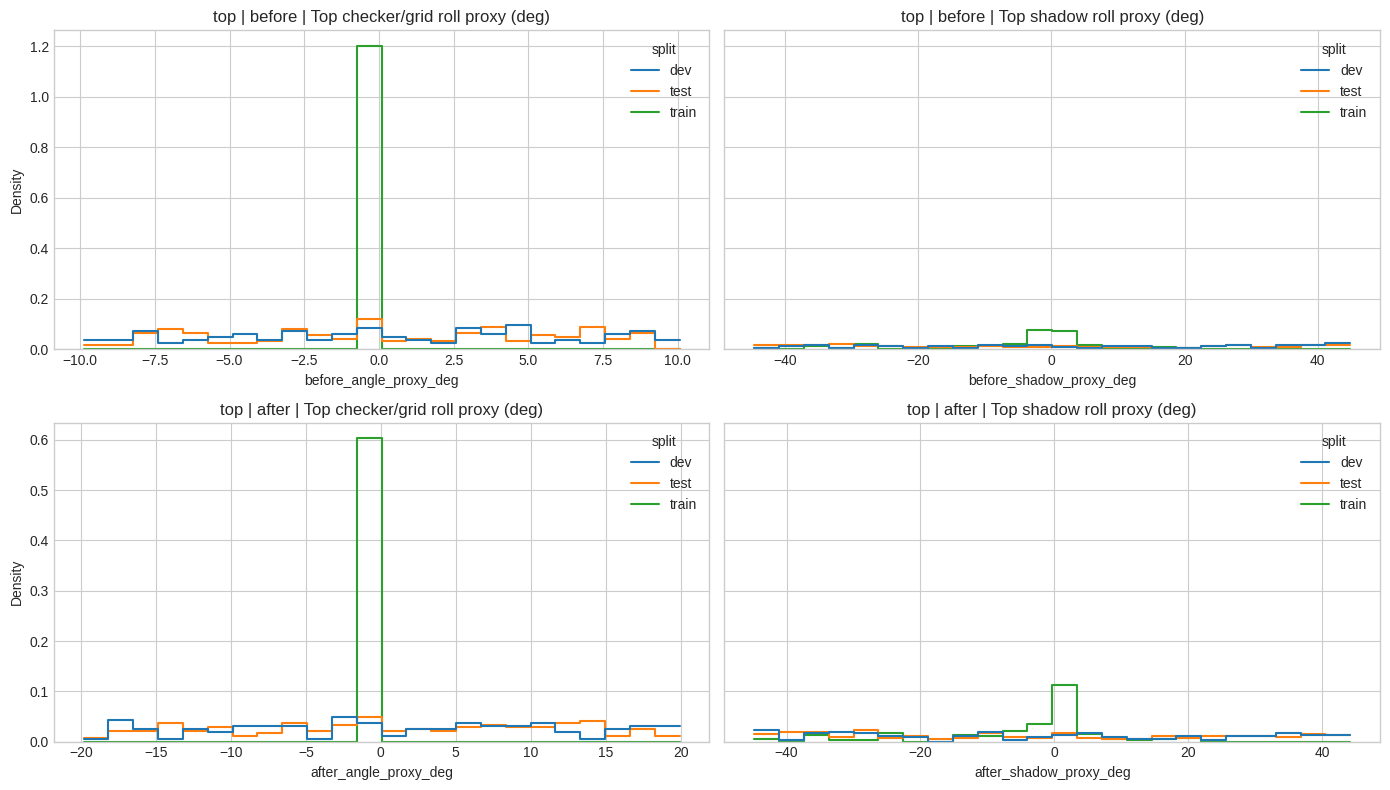

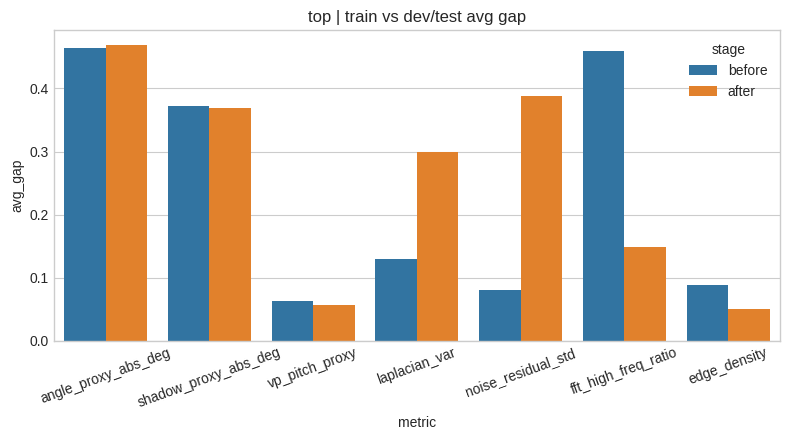

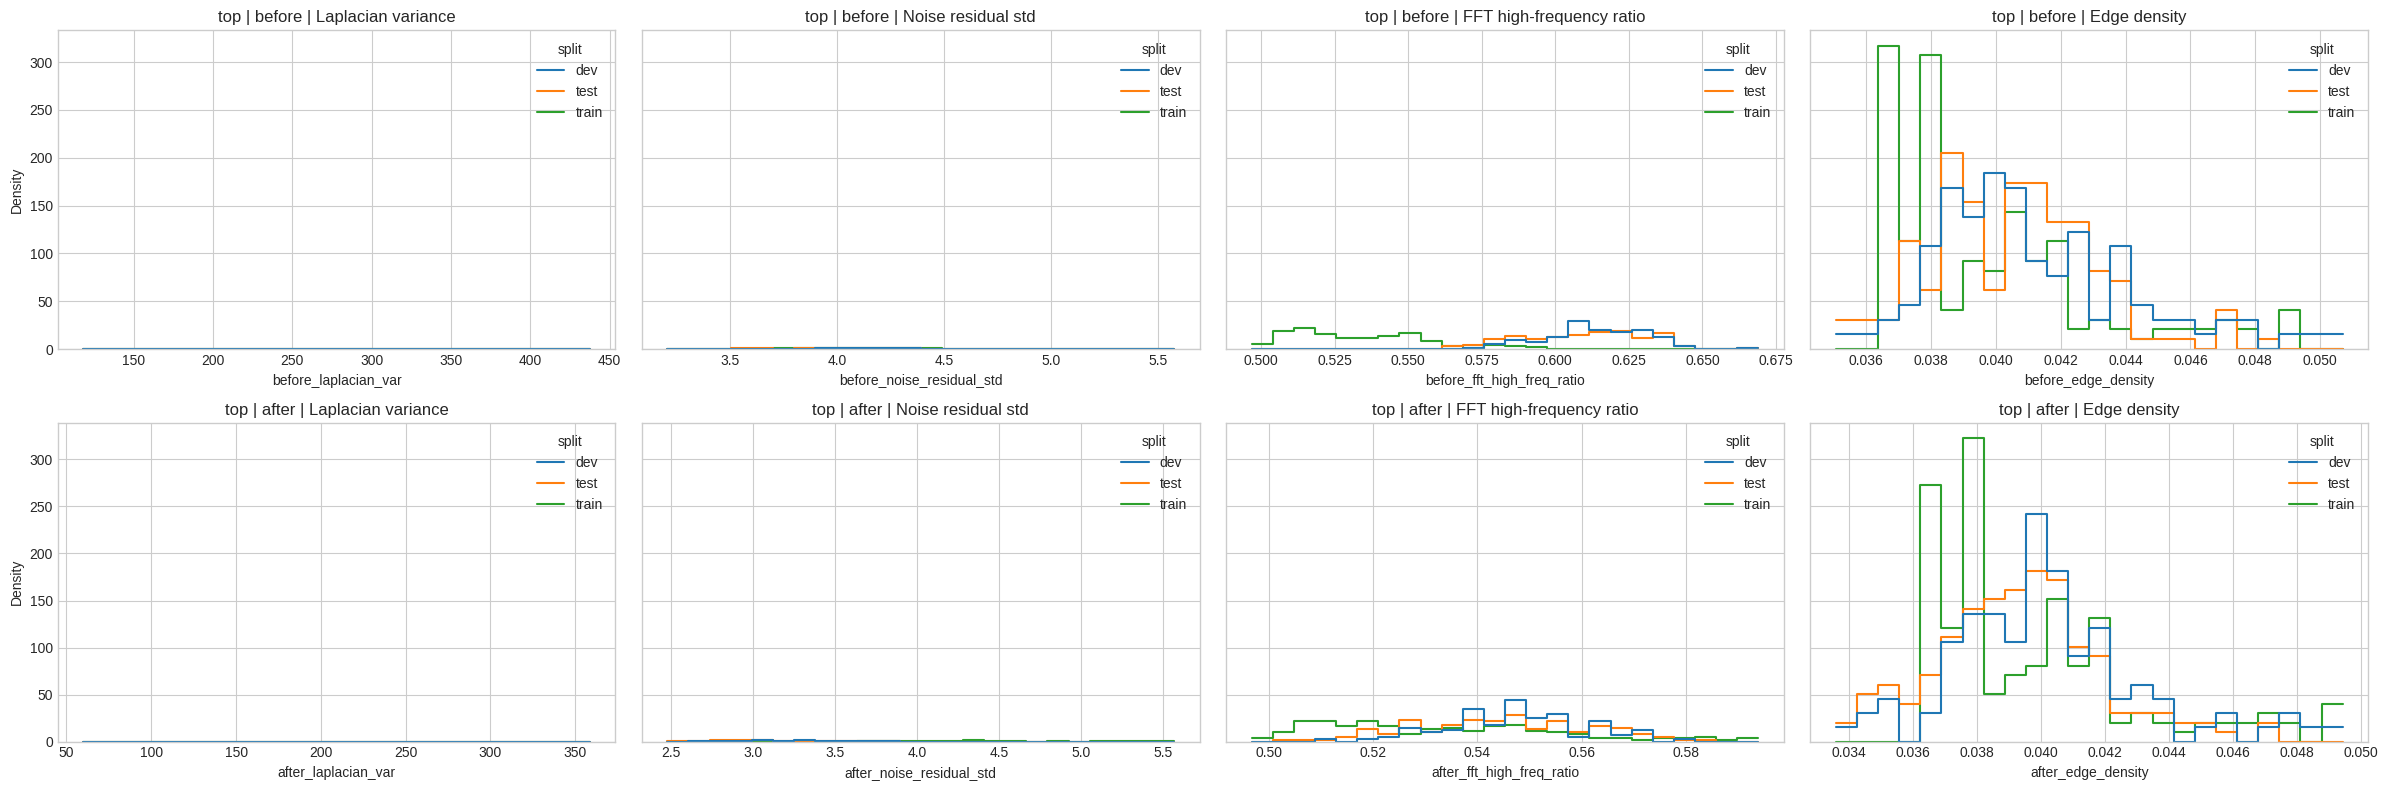

In [6]:
# Distribution plots: before vs after
plot_cfg = {
    'top': [
        ('angle_proxy_deg', 'Top checker/grid roll proxy (deg)'),
        ('shadow_proxy_deg', 'Top shadow roll proxy (deg)'),
    ],
}

for view, cols in plot_cfg.items():
    fig, axes = plt.subplots(2, len(cols), figsize=(7 * len(cols), 8), sharey='row')
    if len(cols) == 1:
        axes = np.array([[axes[0]], [axes[1]]])
    for col_idx, (metric, title) in enumerate(cols):
        sns.histplot(
            data=rotation_df.query('view == @view'),
            x=f'before_{metric}',
            hue='split',
            bins=24,
            stat='density',
            common_norm=False,
            element='step',
            fill=False,
            ax=axes[0, col_idx],
        )
        axes[0, col_idx].set_title(f'{view} | before | {title}')

        sns.histplot(
            data=rotation_df.query('view == @view'),
            x=f'after_{metric}',
            hue='split',
            bins=24,
            stat='density',
            common_norm=False,
            element='step',
            fill=False,
            ax=axes[1, col_idx],
        )
        axes[1, col_idx].set_title(f'{view} | after | {title}')
    plt.tight_layout()

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
part = gap_df.query('view == "top"').copy()
sns.barplot(data=part, x='metric', y='avg_gap', hue='stage', ax=ax)
ax.set_title('top | train vs dev/test avg gap')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
frequency_plot_cfg = [
    ('laplacian_var', 'Laplacian variance'),
    ('noise_residual_std', 'Noise residual std'),
    ('fft_high_freq_ratio', 'FFT high-frequency ratio'),
    ('edge_density', 'Edge density'),
]

for view in ['top']:
    fig, axes = plt.subplots(2, len(frequency_plot_cfg), figsize=(6 * len(frequency_plot_cfg), 8), sharey='row')
    for col_idx, (metric, title) in enumerate(frequency_plot_cfg):
        sns.histplot(
            data=rotation_df.query('view == @view'),
            x=f'before_{metric}',
            hue='split',
            bins=24,
            stat='density',
            common_norm=False,
            element='step',
            fill=False,
            ax=axes[0, col_idx],
        )
        axes[0, col_idx].set_title(f'{view} | before | {title}')

        sns.histplot(
            data=rotation_df.query('view == @view'),
            x=f'after_{metric}',
            hue='split',
            bins=24,
            stat='density',
            common_norm=False,
            element='step',
            fill=False,
            ax=axes[1, col_idx],
        )
        axes[1, col_idx].set_title(f'{view} | after | {title}')
    plt.tight_layout()


,sample_id,view,split,estimated_rotation_angle_deg,applied_rotation_angle_deg,before_angle_proxy_deg,after_angle_proxy_deg,before_shadow_proxy_deg,after_shadow_proxy_deg
0,DEV_023,top,dev,-0.6402,-0.6402,0.6701,1.3639,23.4203,24.0244
1,TEST_0078,top,test,6.0254,6.0254,-6.0377,-11.9933,-31.1264,-34.7388
2,TEST_0417,top,test,-6.0401,-6.0401,5.9778,11.8887,-42.6655,-39.3256
3,TEST_0619,top,test,-8.4411,-8.4411,8.1825,16.9180,-19.4117,-10.6429


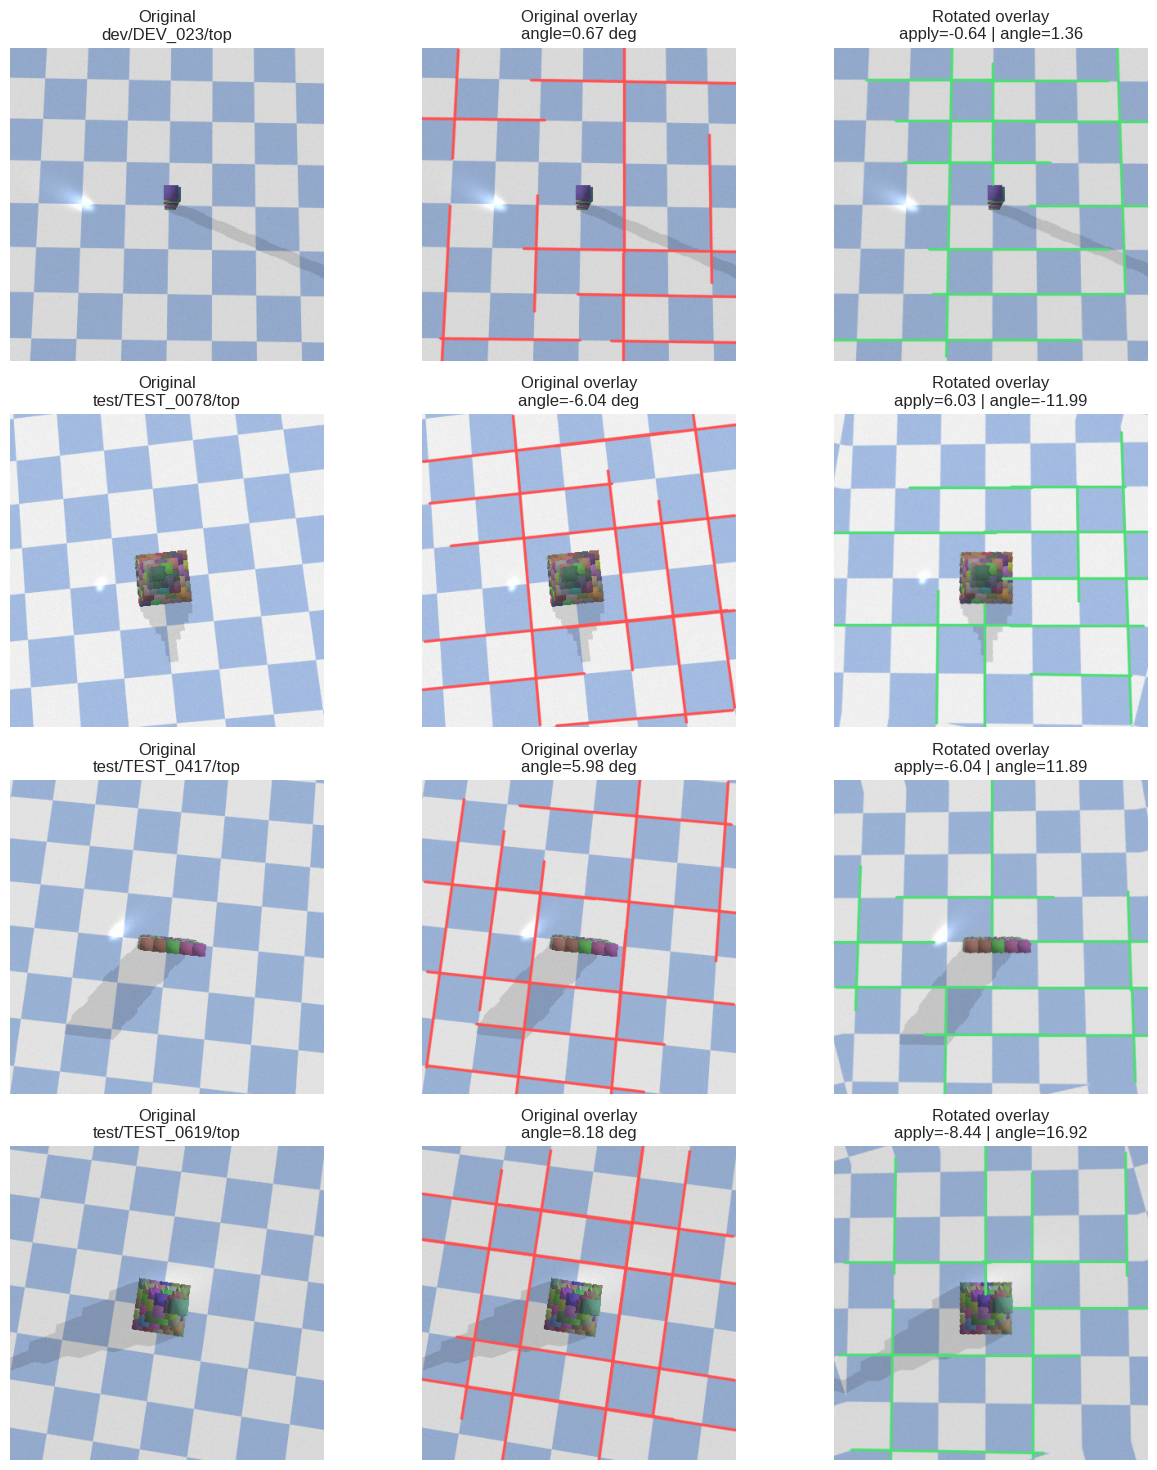

In [ ]:
# Sample visualization: original vs rotated

def overlay_lines(rgb: np.ndarray, lines: list[tuple[int, int, int, int, float, float]], color=(255, 80, 80)) -> np.ndarray:
    out = rgb.copy()
    for x1, y1, x2, y2, _, _ in lines[:12]:
        cv2.line(out, (x1, y1), (x2, y2), color, 2, cv2.LINE_AA)
    return out


def show_rotation_examples(view: str, n_samples: int = 4, seed: int = RANDOM_STATE) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    part = rotation_df.query('view == @view and split != "train"').copy()
    chosen_idx = rng.choice(part.index.to_numpy(), size=min(n_samples, len(part)), replace=False)
    chosen = part.loc[chosen_idx].sort_values('sample_id').reset_index(drop=True)

    fig, axes = plt.subplots(len(chosen), 3, figsize=(13, 3.7 * len(chosen)))
    if len(chosen) == 1:
        axes = np.array([axes])

    summary_rows = []
    for ax_row, row in zip(axes, chosen.itertuples(index=False)):
        original_rgb = read_rgb(Path(row.image_path))
        rotated_rgb = rotate_rgb(original_rgb, -row.rot_applied_rotation_deg)
        orig_gray = cv2.cvtColor(original_rgb, cv2.COLOR_RGB2GRAY)
        rot_gray = cv2.cvtColor(rotated_rgb, cv2.COLOR_RGB2GRAY)

        if view == 'top':
            orig_lines = detect_checker_lines(orig_gray, 'top')
            rot_lines = detect_checker_lines(rot_gray, 'top')
        else:
            orig_lines = detect_horizon_lines(orig_gray)
            rot_lines = detect_horizon_lines(rot_gray)

        orig_overlay = overlay_lines(original_rgb, orig_lines)
        rot_overlay = overlay_lines(rotated_rgb, rot_lines, color=(80, 220, 120))

        titles = [
            f'Original\n{row.split}/{row.sample_id}/{view}',
            f'Original overlay\nangle={row.before_angle_proxy_deg:.2f} deg',
            f'Rotated overlay\napply={row.rot_applied_rotation_deg:.2f} | angle={row.after_angle_proxy_deg:.2f}',
        ]
        for ax, img, title in zip(ax_row, [original_rgb, orig_overlay, rot_overlay], titles):
            ax.imshow(img)
            ax.set_title(title)
            ax.axis('off')

        summary_rows.append({
            'sample_id': row.sample_id,
            'view': view,
            'split': row.split,
            'estimated_rotation_angle_deg': row.rot_rotation_angle_deg,
            'applied_rotation_angle_deg': row.rot_applied_rotation_deg,
            'before_angle_proxy_deg': row.before_angle_proxy_deg,
            'after_angle_proxy_deg': row.after_angle_proxy_deg,
            'before_shadow_proxy_deg': row.before_shadow_proxy_deg,
            'after_shadow_proxy_deg': row.after_shadow_proxy_deg,
        })

    plt.tight_layout()
    return pd.DataFrame(summary_rows).round(4)


display(show_rotation_examples('top', n_samples=4))

## Reading Notes

해석 팁
- `train`은 기준 분포라서 실제 회전 적용값은 `0`이고, `dev/test`의 `top`만 `rot_applied_rotation_deg`만큼 회전됩니다.
- `top`의 회전각은 `train top` 격자가 화면 축과 직교하다는 가정 아래 체커보드 선 각도만으로 계산합니다. 정규화 후 `angle_proxy_deg`가 `0` 근처로 모이면 의도대로 동작한 것입니다.
- `front`의 `angle_proxy_deg`는 참고용 지표로만 남기고, 구조정보 보존을 위해 실제 회전 정규화는 적용하지 않습니다.
- `shadow_proxy_deg`는 그림자 축 변화가 회전 정규화 이후 얼마나 줄었는지 보는 보조 지표일 뿐, 회전각 계산에는 사용하지 않습니다.
- `vp_pitch_proxy`는 회전만으로 완전히 맞추기 어려운 원근 차이를 보는 참고용 지표입니다.
- `avg_gap`은 `train`과 `dev/test`의 ECDF 평균 차이입니다. `after`가 더 작아지면 분포 정렬에 도움이 된 것입니다.

- `laplacian_var`, `noise_residual_std`, `fft_high_freq_ratio`, `edge_density`는 회전으로 격자 방향이 정렬될 때 split별 주파수 통계도 같이 움직이는지 보기 위한 지표입니다.
